In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv("sales.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pizza_id           48620 non-null  int64  
 1   order_id           48620 non-null  int64  
 2   pizza_name_id      48620 non-null  object 
 3   quantity           48620 non-null  int64  
 4   order_date         48620 non-null  object 
 5   order_time         48620 non-null  object 
 6   unit_price         48620 non-null  float64
 7   total_price        48620 non-null  float64
 8   pizza_size         48620 non-null  object 
 9   pizza_category     48620 non-null  object 
 10  pizza_ingredients  48620 non-null  object 
 11  pizza_name         48620 non-null  object 
 12  datetime           48620 non-null  object 
dtypes: float64(2), int64(3), object(8)
memory usage: 4.8+ MB


In [ ]:
df.isnull().sum()

pizza_id              0
order_id              0
pizza_name_id        16
quantity              0
order_date            0
order_time            0
unit_price            0
total_price           7
pizza_size            0
pizza_category       23
pizza_ingredients    13
pizza_name            7
dtype: int64

#### Null values filling

In [ ]:
# Pizza Name ID
null_rows = df[df['pizza_name_id'].isna()].copy()

for i in range(len(null_rows)):
    name= null_rows.iloc[i]["pizza_name"]
    size= null_rows.iloc[i]["pizza_size"]
    value=df[(df["pizza_name"] == name) & (df["pizza_size"] ==size) &(df["pizza_name_id"].notna())]['pizza_name_id'].values[0]

    df.loc[(df["pizza_name"] == name) & (df["pizza_size"] ==size), "pizza_name_id"] = value


In [ ]:
# Total prize
null_rows = df[df['total_price'].isna()].copy()

for i in range(len(null_rows)):
    name= null_rows.iloc[i]["pizza_name"]
    size= null_rows.iloc[i]["pizza_size"]
    value=df[(df["pizza_name"] == name) & (df["pizza_size"] ==size) &(df["total_price"].notna())]['total_price'].values[0]

    df.loc[(df["pizza_name"] == name) & (df["pizza_size"] ==size)&(df["total_price"].isna()), "total_price"] = value

In [ ]:
# Pizza category
null_rows = df[df['pizza_category'].isna()].copy()

for i in range(len(null_rows)):
    name= null_rows.iloc[i]["pizza_name"]
    value=df[(df["pizza_name"] == name) &(df["pizza_category"].notna())]['pizza_category'].values[0]

    df.loc[(df["pizza_name"] == name) &(df["pizza_category"].isna()), "pizza_category"] = value

In [ ]:
# Pizza ingredients
null_rows = df[df['pizza_ingredients'].isna()].copy()

for i in range(len(null_rows)):
    name= null_rows.iloc[i]["pizza_name_id"]
    value=df[(df["pizza_name_id"] == name) &(df["pizza_ingredients"].notna())]['pizza_ingredients'].values[0]

    df.loc[(df["pizza_name_id"] == name) &(df["pizza_ingredients"].isna()), "pizza_ingredients"] = value

In [ ]:
# Pizza name
null_rows = df[df['pizza_name'].isna()].copy()

for i in range(len(null_rows)):
    name= null_rows.iloc[i]["pizza_name_id"]
    value=df[(df["pizza_name_id"] == name) &(df["pizza_name"].notna())]['pizza_name'].values[0]

    df.loc[(df["pizza_name_id"] == name) &(df["pizza_name"].isna()), "pizza_name"] = value

In [ ]:
df.isnull().sum()

pizza_id             0
order_id             0
pizza_name_id        0
quantity             0
order_date           0
order_time           0
unit_price           0
total_price          0
pizza_size           0
pizza_category       0
pizza_ingredients    0
pizza_name           0
dtype: int64

#### Feature engineering 'order_date' and 'order_time' column

In [5]:
df["order_date"]=pd.to_datetime(df['order_date'])

In [ ]:
df["datetime"]=df["order_date"].astype(str) +" "+ df["order_time"].astype(str)

In [4]:
df["datetime"] = pd.to_datetime(df["datetime"])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   pizza_id           48620 non-null  int64         
 1   order_id           48620 non-null  int64         
 2   pizza_name_id      48620 non-null  object        
 3   quantity           48620 non-null  int64         
 4   order_date         48620 non-null  datetime64[ns]
 5   order_time         48620 non-null  object        
 6   unit_price         48620 non-null  float64       
 7   total_price        48620 non-null  float64       
 8   pizza_size         48620 non-null  object        
 9   pizza_category     48620 non-null  object        
 10  pizza_ingredients  48620 non-null  object        
 11  pizza_name         48620 non-null  object        
 12  datetime           48620 non-null  datetime64[ns]
dtypes: datetime64[ns](2), float64(2), int64(3), object(6)
memory 

In [ ]:
df.to_csv("sales.csv",index=False)

#### Pizza_ingredients.csv null values filling

In [ ]:
data = pd.read_csv("Pizza_ingredients.csv")

In [ ]:
data

,pizza_name_id,pizza_name,pizza_ingredients,Items_Qty_In_Grams
0,bbq_ckn_l,The Barbecue Chicken Pizza,Barbecued Chicken,40.0
1,bbq_ckn_l,The Barbecue Chicken Pizza,Red Peppers,15.0
2,bbq_ckn_l,The Barbecue Chicken Pizza,Green Peppers,20.0
3,bbq_ckn_l,The Barbecue Chicken Pizza,Tomatoes,30.0
4,bbq_ckn_l,The Barbecue Chicken Pizza,Red Onions,60.0
...,...,...,...,...
513,veggie_veg_s,The Vegetables + Vegetables Pizza,Green Peppers,20.0
514,veggie_veg_s,The Vegetables + Vegetables Pizza,Red Onions,20.0
515,veggie_veg_s,The Vegetables + Vegetables Pizza,Zucchini,10.0
516,veggie_veg_s,The Vegetables + Vegetables Pizza,Spinach,15.0


In [ ]:
data.isnull().sum()

pizza_name_id         0
pizza_name            0
pizza_ingredients     0
Items_Qty_In_Grams    0
dtype: int64

In [ ]:
# Sliced Ham
data.loc[[149,152,155],'Items_Qty_In_Grams']= [50,100,150]

In [ ]:
# Caramelized Onions
data.loc[24,'Items_Qty_In_Grams']= 25

In [ ]:
data.to_csv("ingredients.csv",index=False)

## EDA

In [ ]:
df.columns

Index(['pizza_id', 'order_id', 'pizza_name_id', 'quantity', 'order_date',
       'order_time', 'unit_price', 'total_price', 'pizza_size',
       'pizza_category', 'pizza_ingredients', 'pizza_name', 'datetime', 'day',
       'month', 'year', 'day_of_week', 'quarter', 'hour', 'minute', 'second'],
      dtype='object')

- #### Outliers

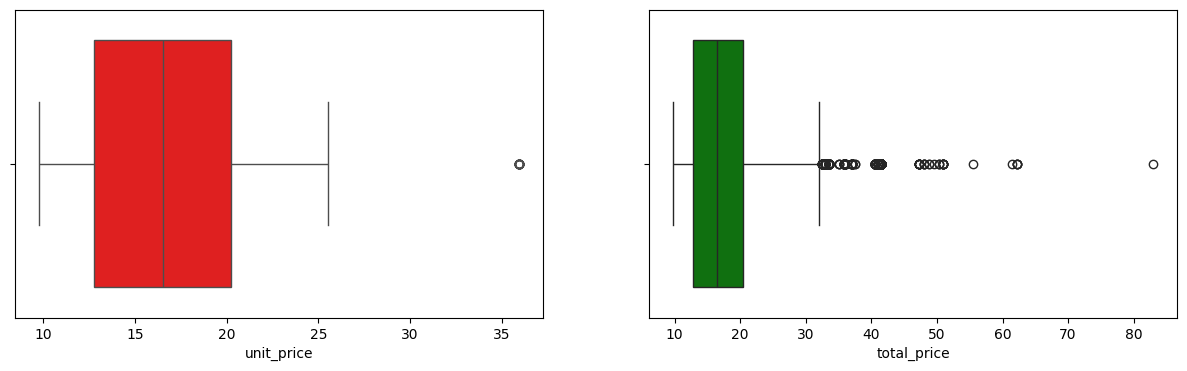

In [ ]:
fig, axes = plt.subplots(1,2,figsize=(15,4))
sns.boxplot(data=df, x='unit_price',ax=axes[0],color="r")
sns.boxplot(data=df, x='total_price',ax=axes[1],color="g")
plt.show()

- #### bar plot

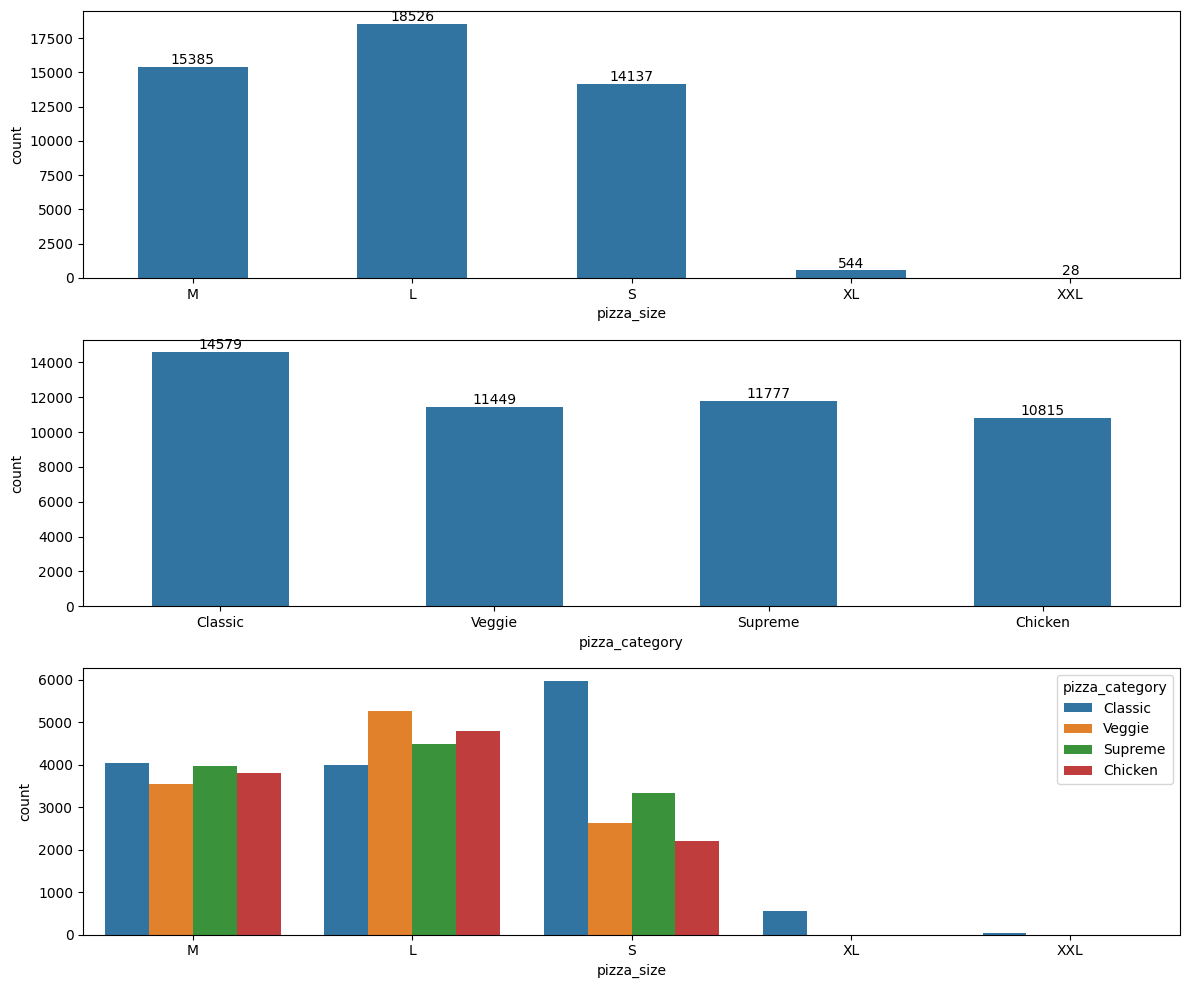

In [ ]:
# Bar chart for pizza sold in different size
fig, axes = plt.subplots(3,1,figsize=(12,10))
sns.countplot(data=df,x="pizza_size",width=0.5,ax=axes[0])
axes[0].bar_label(axes[0].containers[0])

sns.countplot(data=df,x="pizza_category",width=0.5,ax=axes[1])
axes[1].bar_label(axes[1].containers[0])

sns.countplot(data=df,x="pizza_size",hue="pizza_category",legend=True,ax=axes[2])

plt.tight_layout()
plt.show()

In [ ]:
# Each pizza's sales
each_pizza_sales=df.groupby(["pizza_name","pizza_category"])["quantity"].sum().sort_values().reset_index()
each_pizza_sales

,pizza_name,pizza_category,quantity
0,The Brie Carre Pizza,Supreme,490
1,The Mediterranean Pizza,Veggie,934
2,The Calabrese Pizza,Supreme,937
3,The Spinach Supreme Pizza,Supreme,950
4,The Soppressata Pizza,Supreme,961
5,The Spinach Pesto Pizza,Veggie,970
6,The Chicken Pesto Pizza,Chicken,973
7,The Italian Vegetables Pizza,Veggie,981
8,The Chicken Alfredo Pizza,Chicken,987
9,The Green Garden Pizza,Veggie,997


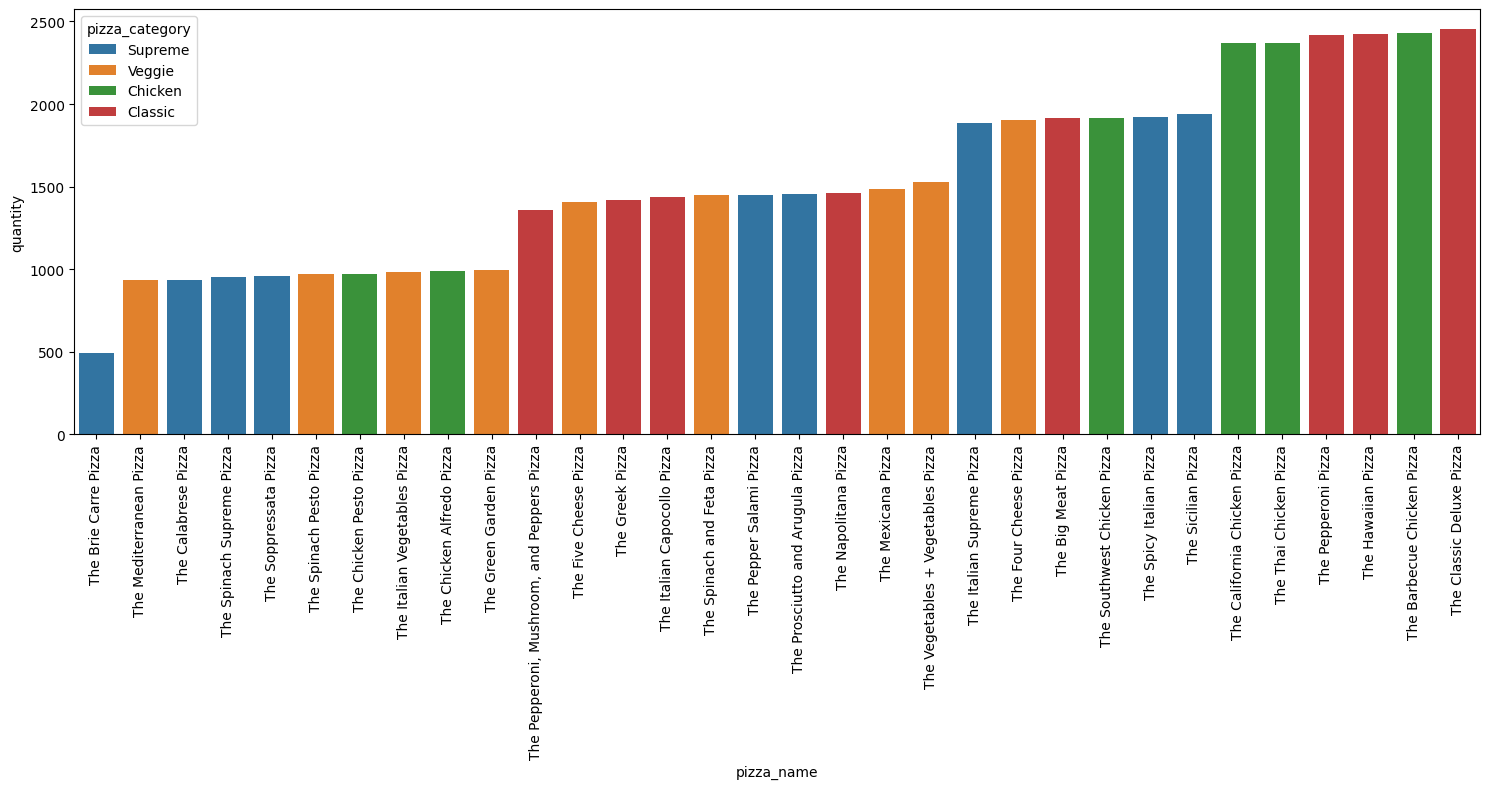

In [ ]:
plt.figure(figsize=(15,8))
sns.barplot(data=each_pizza_sales,x='pizza_name',y="quantity",hue="pizza_category")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

- ### Daily pizza sales

In [8]:
daily_sales = df.groupby('order_date')['quantity'].sum().reset_index()
daily_sales.columns = ['date', 'total_pizzas_sold']

#daily_sales.set_index("date",inplace=True)
daily_sales["date"]= pd.to_datetime(daily_sales["date"])

daily_sales

,date,total_pizzas_sold
0,2015-01-01,162
1,2015-01-02,191
2,2015-01-03,99
3,2015-01-04,135
4,2015-01-05,154
...,...,...
353,2015-12-27,89
354,2015-12-28,102
355,2015-12-29,80
356,2015-12-30,82


- #### Filling Missing Dates by Interpolation Method

In [5]:
all_dates=df["order_date"].unique()

In [6]:
full_range = pd.date_range(start=all_dates.min(), end=all_dates.max(), freq='D')

In [ ]:
missing_dates = full_range.difference(all_dates)
print("Missing dates:")
print(missing_dates)

Missing dates:
DatetimeIndex(['2015-05-10', '2015-09-24', '2015-09-25', '2015-10-19',
               '2015-10-26', '2015-12-10', '2015-12-25'],
              dtype='datetime64[ns]', freq=None)


In [ ]:
daily_sales.set_index("date",inplace=True)

In [ ]:
daily_sales = daily_sales.reindex(full_range)

In [ ]:
daily_sales.isna().sum() # 7 missing dates

,0
total_pizzas_sold,7


In [ ]:
# Interpolation
daily_sales.interpolate(method='time', inplace=True)

In [ ]:
daily_sales = daily_sales.round().astype(int) # Rounding Float to Integer

In [ ]:
daily_sales.loc[['2015-05-10' , '2015-09-24', '2015-09-25', '2015-10-19','2015-10-26', '2015-12-10', '2015-12-25']]

,total_pizzas_sold
2015-05-10,138
2015-09-24,135
2015-09-25,137
2015-10-19,130
2015-10-26,117
2015-12-10,154
2015-12-25,113


In [ ]:
daily_sales = daily_sales.reset_index().rename(columns={'index': 'date'})

daily_sales

,date,total_pizzas_sold
0,2015-01-01,162
1,2015-01-02,191
2,2015-01-03,99
3,2015-01-04,135
4,2015-01-05,154
...,...,...
353,2015-12-27,89
354,2015-12-28,102
355,2015-12-29,80
356,2015-12-30,82


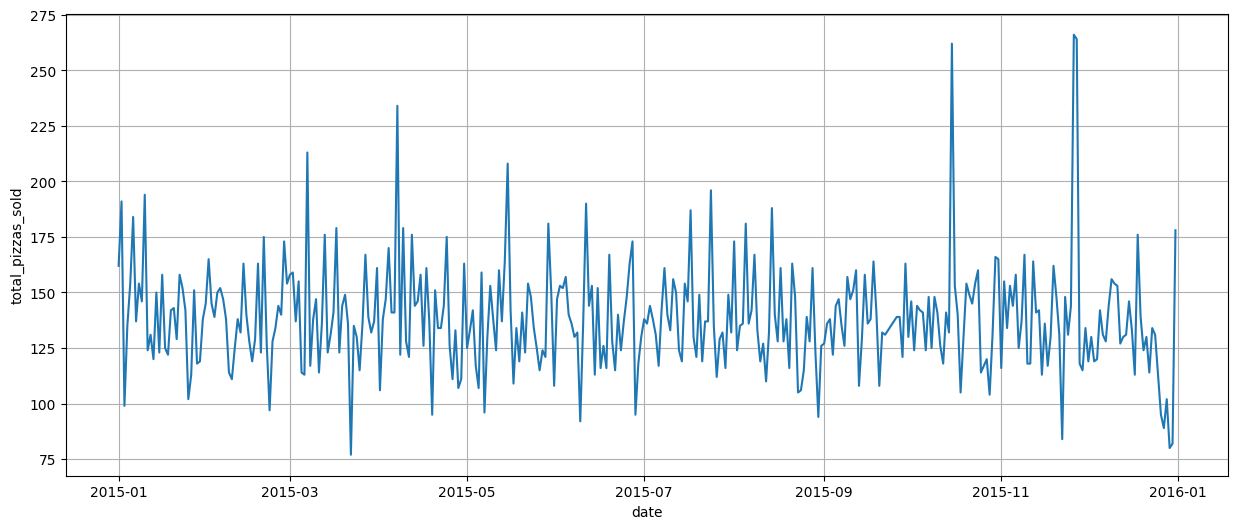

In [ ]:
plt.figure(figsize=(15,6))
sns.lineplot(x=daily_sales["date"],y=daily_sales['total_pizzas_sold'])
plt.grid()
plt.show()

- ### Monthly pizza sales

In [ ]:
monthly_sales = df.groupby([df['order_date'].dt.month])['quantity'].sum().reset_index()
monthly_sales.columns=["months","monthly sales"]
monthly_sales

,months,monthly sales
0,1,4361
1,2,3893
2,3,4332
3,4,4259
4,5,4083
5,6,4123
6,7,4310
7,8,4222
8,9,3860
9,10,4122


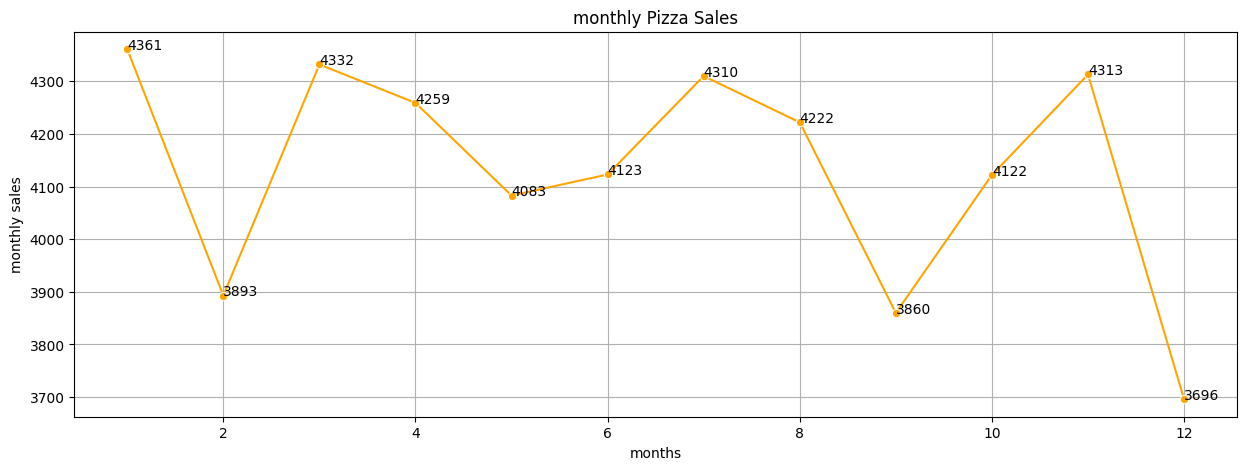

In [ ]:
plt.figure(figsize=(15,5))
ax=sns.lineplot(x=monthly_sales['months'],y=monthly_sales['monthly sales'],marker="o",color="orange")
for x, y in zip(monthly_sales['months'], monthly_sales['monthly sales']):
    ax.text(x, y, y)
plt.title("monthly Pizza Sales")
plt.grid()
plt.show()

- ### weekly pizza sales

<Axes: xlabel='week'>

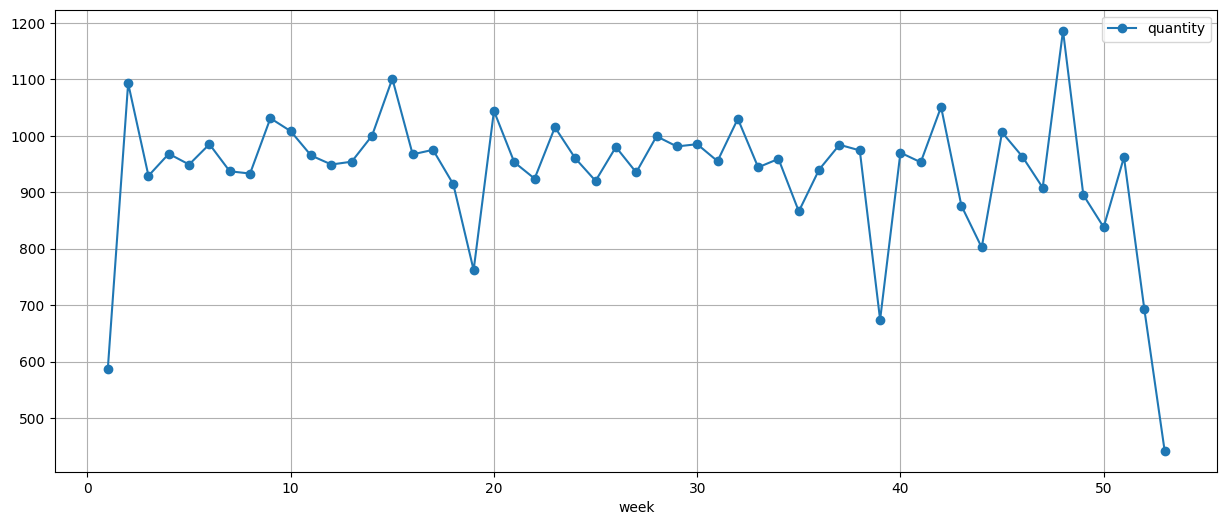

In [18]:
df.groupby(["week"])["quantity"].sum().reset_index().plot(x="week",y="quantity",kind="line", figsize=(15, 6), marker='o',grid=True)

- #### 3 months of daily sales exploring

In [ ]:
# First 3 months sales
month_count = daily_sales.iloc[:92].copy()
month_count["day"]=month_count["date"].dt.day_name()

C:\Users\HP\AppData\Local\Temp\ipykernel_8400\3167347101.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  month_count["day"]=month_count["date"].dt.day_name()


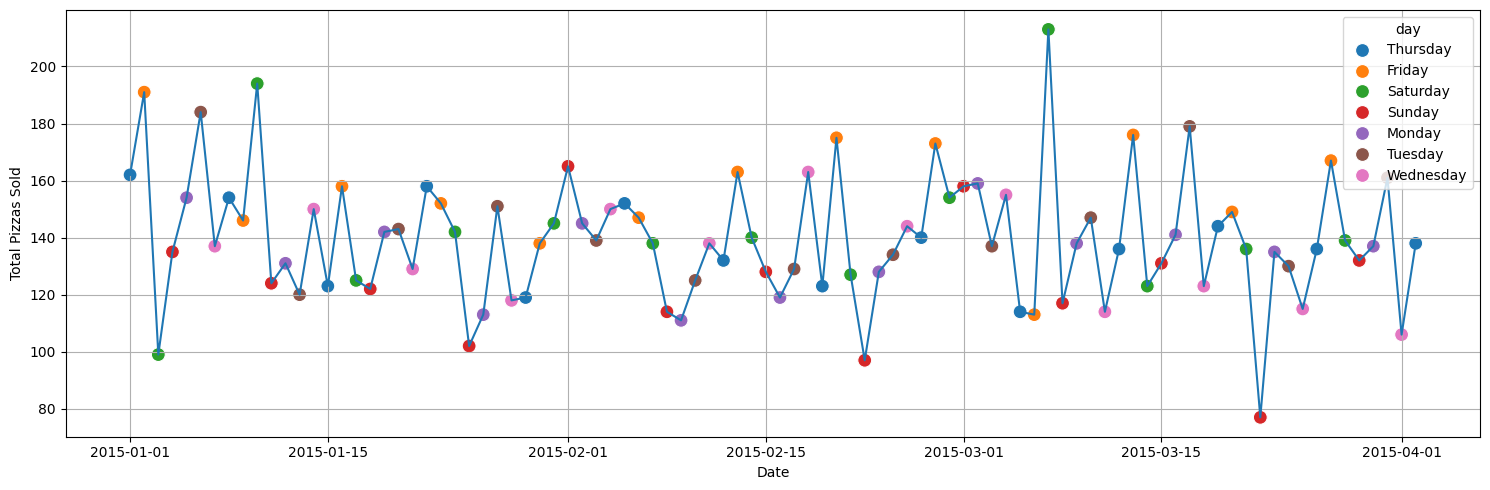

In [ ]:
plt.figure(figsize=(15, 5))
sns.lineplot(data=month_count,x="date",y='total_pizzas_sold')
sns.scatterplot(data=month_count,x="date",y='total_pizzas_sold',hue='day',legend=True,s=100)
plt.xlabel("Date")
plt.ylabel("Total Pizzas Sold")
plt.tight_layout()
plt.grid()
plt.show()

- ### Hourly pizza sales

In [ ]:
# To identify peak sales hours
df["hour"]=df["datetime"].dt.hour

hourly_sales=df.groupby("hour")["quantity"].sum().reset_index().sort_values(by="hour")
hourly_sales

,hour,quantity
0,9,4
1,10,18
2,11,2728
3,12,6776
4,13,6413
5,14,3613
6,15,3216
7,16,4239
8,17,5211
9,18,5417


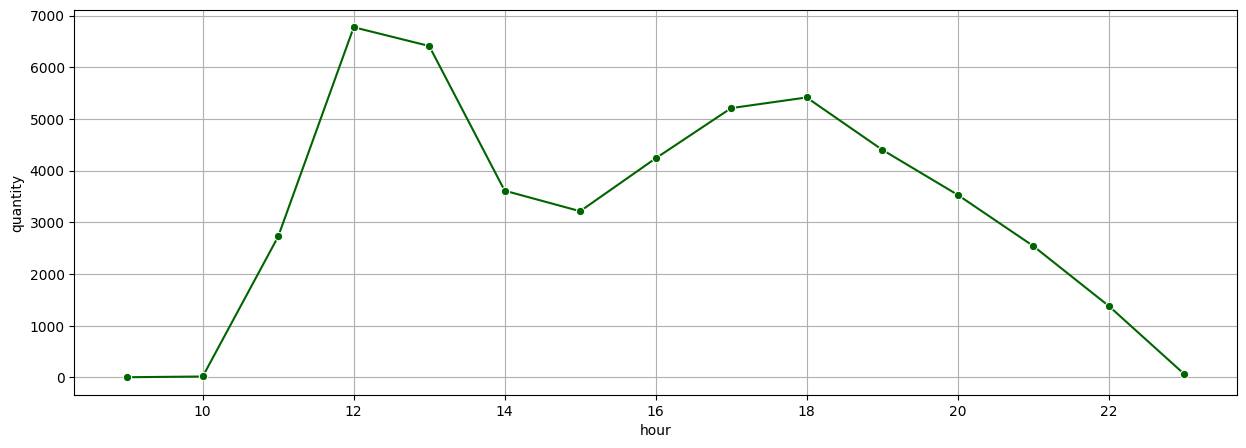

In [ ]:
plt.figure(figsize=(15,5))
sns.lineplot(data=hourly_sales#[hourly_sales["order_date"]=="2015-01-01"]
             ,x="hour",y="quantity",marker="o",color="darkgreen")
plt.grid()
plt.show()

### pizza's sales by each day

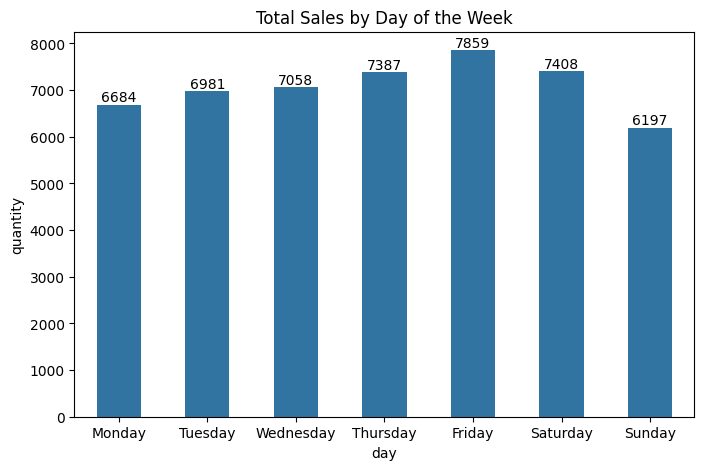

In [ ]:
# Total sales by day of the week
#df["day"]=df["order_date"].dt.day_name()
sales_by_days=df.groupby("day")["quantity"].sum().reset_index()
plt.figure(figsize=(8,5))
ax=sns.barplot(data=sales_by_days,x='day',y='quantity',order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday', 'Sunday'],width=0.5,legend='auto')
ax.bar_label(ax.containers[0])
plt.title("Total Sales by Day of the Week")
plt.show()

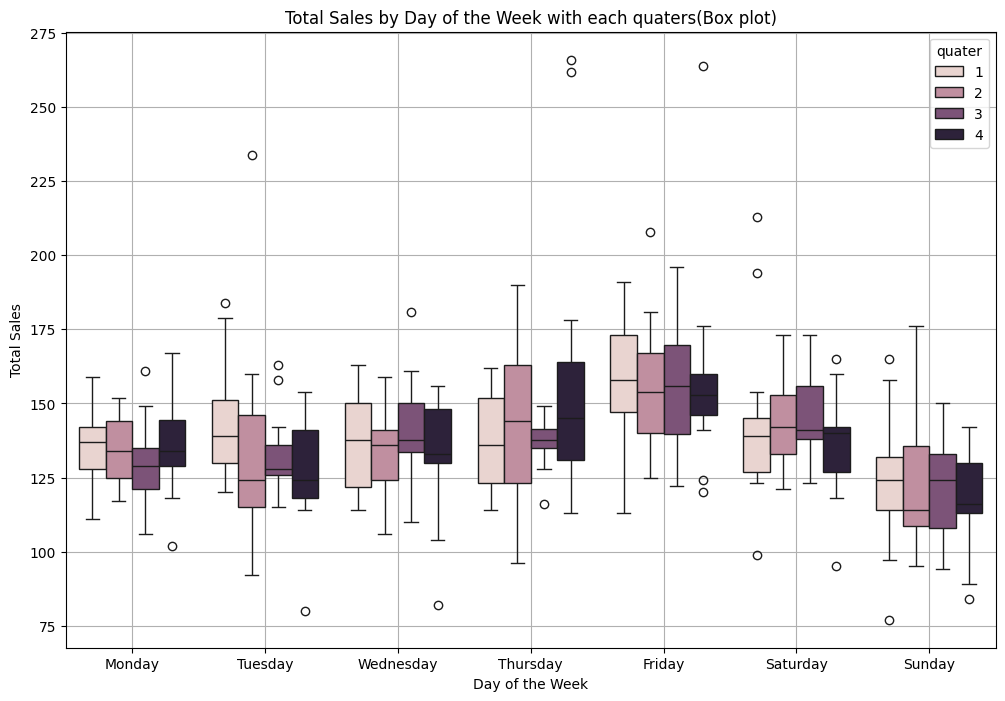

In [25]:
grouped_df = df.groupby("order_date")["quantity"].sum().reset_index()
grouped_df["day_name"] = pd.to_datetime(grouped_df["order_date"]).dt.day_name()
grouped_df["quater"] = pd.to_datetime(grouped_df["order_date"]).dt.quarter
plt.figure(figsize=(12,8))
sns.boxplot(data=grouped_df,x='day_name',y='quantity',order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday', 'Sunday'],legend='auto',hue='quater')
plt.title("Total Sales by Day of the Week with each quaters(Box plot)")
plt.xlabel("Day of the Week")
plt.ylabel("Total Sales")
plt.legend(title="quater")
plt.grid()
plt.show()

### Grouping using "pizza_name_id", so that we can easily seperate dataframe of each pizza's for univarient models.

In [7]:
data=df.groupby(["order_date","pizza_name_id"])["quantity"].sum().reset_index()
data

,order_date,pizza_name_id,quantity
0,2015-01-01,bbq_ckn_l,6
1,2015-01-01,bbq_ckn_m,4
2,2015-01-01,bbq_ckn_s,1
3,2015-01-01,big_meat_s,5
4,2015-01-01,calabrese_m,1
...,...,...,...
22959,2015-12-31,the_greek_l,1
22960,2015-12-31,the_greek_xl,1
22961,2015-12-31,veggie_veg_l,4
22962,2015-12-31,veggie_veg_m,2


In [ ]:
data[data["pizza_name_id"]=="bbq_ckn_l"]

,order_date,pizza_name_id,quantity
0,2015-01-01,bbq_ckn_l,6
69,2015-01-02,bbq_ckn_l,4
141,2015-01-03,bbq_ckn_l,2
255,2015-01-05,bbq_ckn_l,2
327,2015-01-06,bbq_ckn_l,1
...,...,...,...
22624,2015-12-26,bbq_ckn_l,3
22678,2015-12-27,bbq_ckn_l,1
22797,2015-12-29,bbq_ckn_l,1
22845,2015-12-30,bbq_ckn_l,1


In [ ]:
for i in df["pizza_name_id"].unique():
    temp=data[data["pizza_name_id"]==i]
    print(i," len:",len(temp))

hawaiian_m  len: 270
classic_dlx_m  len: 352
five_cheese_l  len: 346
ital_supr_l  len: 306
mexicana_m  len: 259
thai_ckn_l  len: 351
ital_supr_m  len: 334
prsc_argla_l  len: 251
bbq_ckn_s  len: 260
the_greek_s  len: 215
spinach_supr_s  len: 238
classic_dlx_s  len: 310
green_garden_s  len: 298
ital_cpcllo_l  len: 311
ital_supr_s  len: 148
mexicana_s  len: 125
spicy_ital_l  len: 342
spin_pesto_l  len: 194
veggie_veg_s  len: 253


mexicana_l  len: 315
southw_ckn_l  len: 333
bbq_ckn_l  len: 329
cali_ckn_l  len: 332
cali_ckn_m  len: 332
pepperoni_l  len: 307
cali_ckn_s  len: 279
ckn_pesto_l  len: 238
big_meat_s  len: 357
soppressata_l  len: 240
four_cheese_l  len: 352
napolitana_s  len: 255
calabrese_m  len: 288
four_cheese_m  len: 284
ital_veggie_s  len: 216
mediterraneo_m  len: 183
peppr_salami_s  len: 220
spinach_fet_l  len: 264
napolitana_l  len: 282
sicilian_l  len: 296
ital_cpcllo_m  len: 236
southw_ckn_s  len: 225
bbq_ckn_m  len: 333
pepperoni_m  len: 336
prsc_argla_s  len: 253
sicilian_m  len: 285
veggie_veg_l  len: 251
ckn_alfredo_s  len: 84
pepperoni_s  len: 307
green_garden_l  len: 82
green_garden_m  len: 203
pep_msh_pep_l  len: 226
hawaiian_s  len: 335
peppr_salami_m  len: 260
ckn_alfredo_m  len: 307
peppr_salami_l  len: 304
spin_pesto_s  len: 234
thai_ckn_m  len: 273
classic_dlx_l  len: 261
ckn_pesto_m  len: 186
the_greek_xl  len: 267
hawaiian_l  len: 333
pep_msh_pep_s  len: 292
spinach_supr_m  len: 1

## Pivot dataframe ( another method to seperate dataframe )

In [ ]:
pivot_df=data.pivot(index="order_date",columns="pizza_name_id",values="quantity").fillna(0)

In [ ]:
pivot_df

pizza_name_id,bbq_ckn_l,bbq_ckn_m,bbq_ckn_s,big_meat_s,brie_carre_s,calabrese_l,calabrese_m,calabrese_s,cali_ckn_l,cali_ckn_m,...,thai_ckn_m,thai_ckn_s,the_greek_l,the_greek_m,the_greek_s,the_greek_xl,the_greek_xxl,veggie_veg_l,veggie_veg_m,veggie_veg_s
order_date,,,,,,,,,,,,,,,,,,,,,
2015-01-01,6.0,4.0,1.0,5.0,0.0,0.0,1.0,0.0,2.0,1.0,...,2.0,0.0,0.0,0.0,4.0,1.0,0.0,1.0,0.0,2.0
2015-01-02,4.0,7.0,1.0,9.0,3.0,2.0,5.0,0.0,4.0,9.0,...,1.0,1.0,1.0,1.0,0.0,2.0,0.0,1.0,0.0,0.0
2015-01-03,2.0,0.0,0.0,3.0,1.0,0.0,1.0,0.0,1.0,4.0,...,0.0,2.0,0.0,1.0,1.0,1.0,0.0,3.0,1.0,2.0
2015-01-04,0.0,2.0,0.0,3.0,0.0,1.0,1.0,0.0,2.0,1.0,...,1.0,0.0,0.0,2.0,2.0,2.0,0.0,0.0,2.0,3.0
2015-01-05,2.0,2.0,2.0,1.0,1.0,1.0,2.0,1.0,5.0,5.0,...,3.0,2.0,1.0,2.0,1.0,1.0,0.0,2.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-12-27,1.0,3.0,0.0,5.0,1.0,0.0,1.0,0.0,2.0,1.0,...,1.0,0.0,1.0,0.0,2.0,0.0,0.0,2.0,4.0,3.0
2015-12-28,0.0,1.0,1.0,3.0,1.0,0.0,1.0,0.0,2.0,1.0,...,1.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0
2015-12-29,1.0,3.0,0.0,6.0,1.0,2.0,0.0,0.0,1.0,4.0,...,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0


In [ ]:
pivot_df = pivot_df.reindex(full_range)
pivot_df.interpolate(method='time', inplace=True)
pivot_df = pivot_df.round().astype(int)
pivot_df['total_sold'] = pivot_df.sum(axis=1)

## Seasonal decomposition

In [ ]:
ts = df.groupby("order_date")["quantity"].sum()

In [ ]:
# interpolate technique
ts = ts.reindex(full_range)
ts.interpolate(method='time', inplace=True)
ts = ts.round()

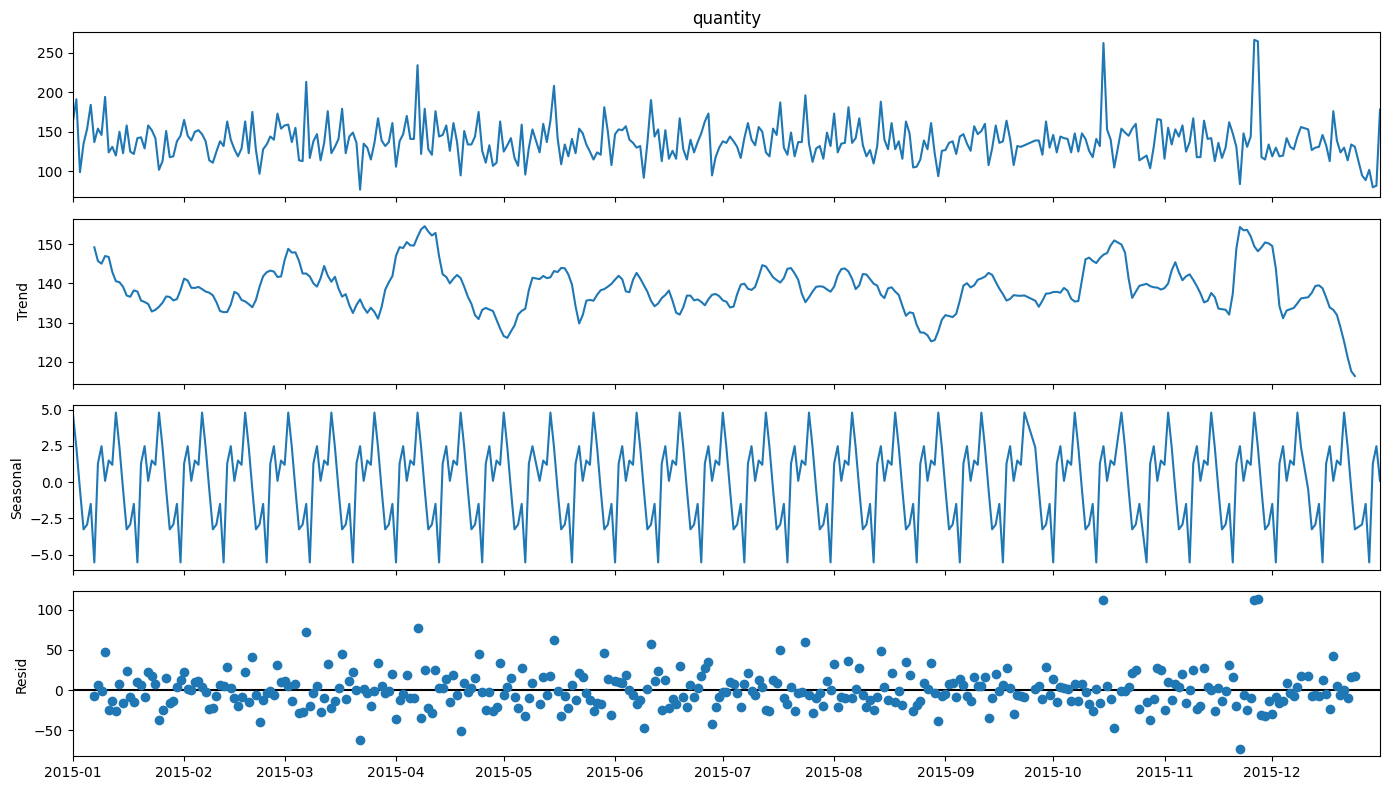

In [ ]:
# Before Interpolation
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(ts, model='additive', period=12)

fig = result.plot()
fig.set_size_inches(14, 8)
plt.tight_layout()
plt.show()

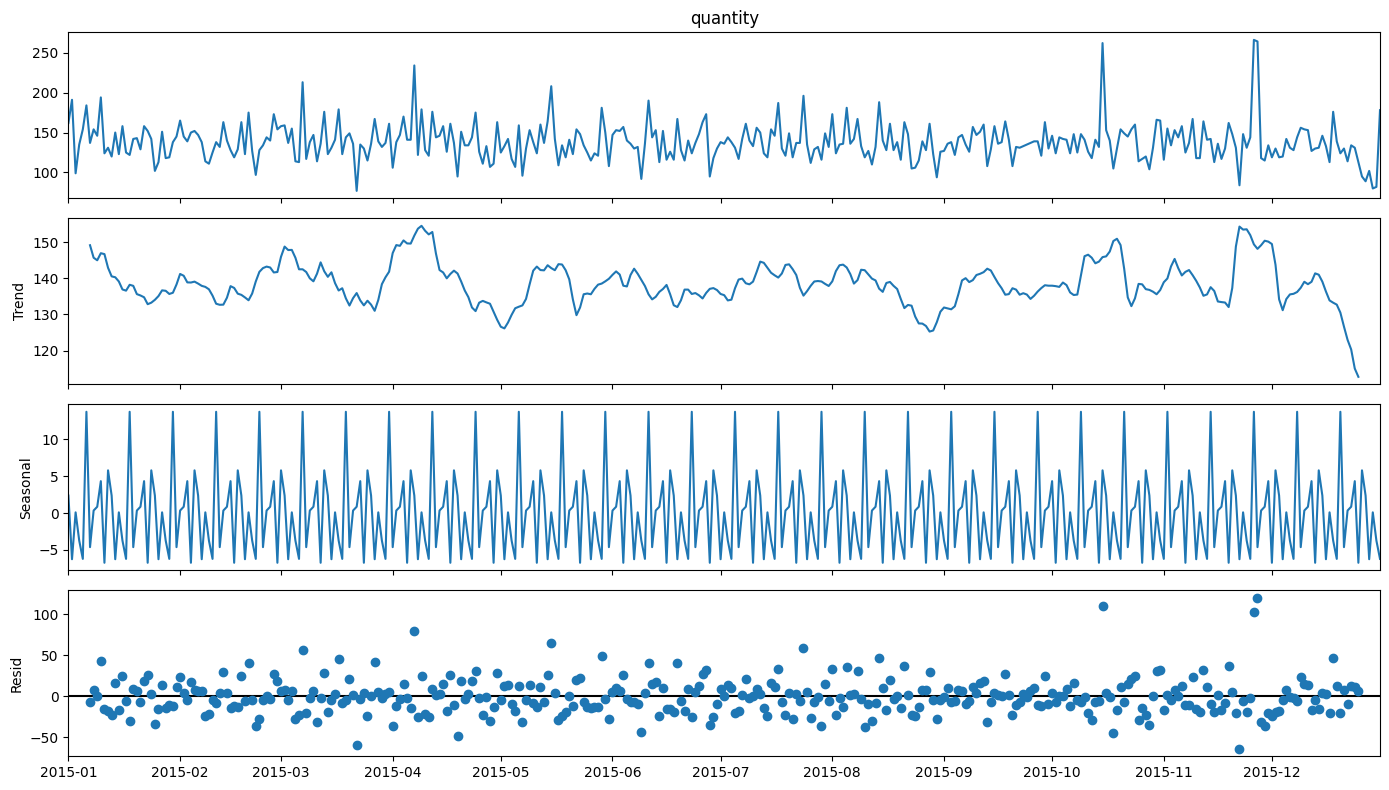

In [ ]:
# Seasonal decomposition after interpolation

from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(ts, model='additive', period=12)

fig = result.plot()
fig.set_size_inches(14, 8)
plt.tight_layout()
plt.show()

## adfuller technique to find stationality of time series

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts)

print('ADF Statistic:', result[0],'\n')

print('p-value:', result[1])
if result[1] < 0.05:
    print("Series is likely stationary (reject null hypothesis).",'\n')
else:
    print("Series is likely non-stationary (fail to reject null hypothesis).",'\n')

print('Critical Values:')
for key, value in result[4].items():
    print(f'{key}: {value}')



ADF Statistic: -9.721220759020508 

p-value: 9.532466404177956e-17
Series is likely stationary (reject null hypothesis). 

Critical Values:
1%: -3.448645946352023
5%: -2.869602139060357
10%: -2.5710650077160495


### Auto correlation plots (ACF and PACF)
used to find p and q parameters in ARIMA model

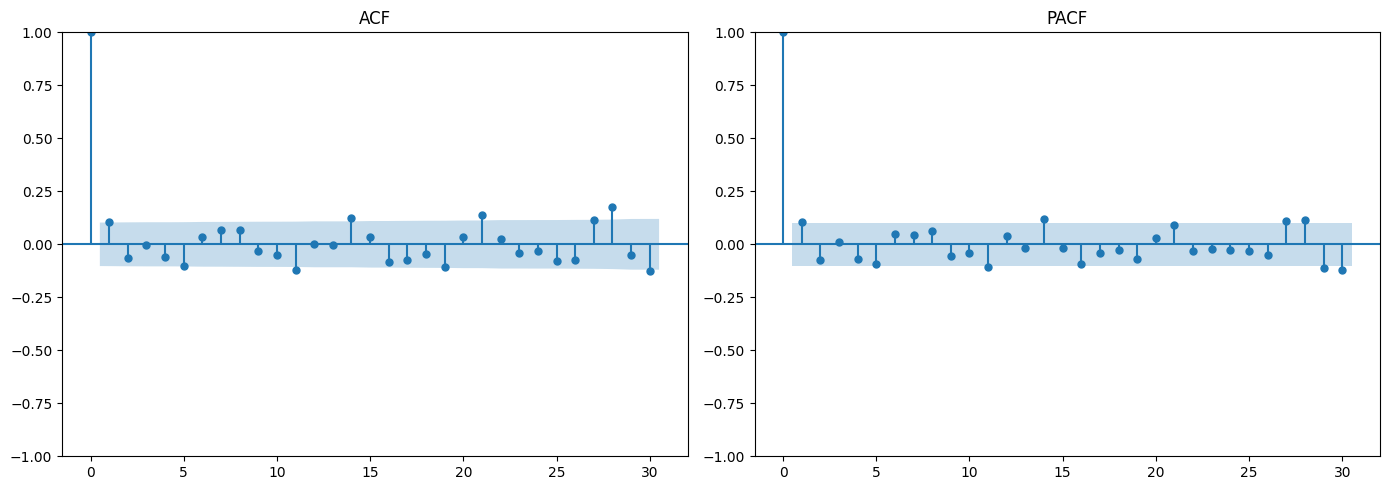

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(ts, lags=30, ax=axes[0])
axes[0].set_title('ACF')

plot_pacf(ts, lags=30, ax=axes[1], method='ywm')
axes[1].set_title('PACF')

plt.tight_layout()
plt.show()


# Statistics models and machine learning models

### Feature Engineering for (RF and XGB)

In [99]:
def extract_date_features(df):
    #df['day'] = df['order_date'].dt.day_name()
    df['month'] = df['order_date'].dt.month
    df['year'] = df['order_date'].dt.year
    df['day_of_week'] = df['order_date'].dt.dayofweek
    df["week"] = df['order_date'].dt.isocalendar().week
    df['quarter'] = df['order_date'].dt.quarter
    #df['hour'] = df['datetime'].dt.hour
    #df['minute'] = df['datetime'].dt.minute
    #df['second'] = df['datetime'].dt.second
    return df

In [ ]:
extract_date_features(df)

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,...,datetime,day,month,year,day_of_week,week,quarter,hour,minute,second
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,13.25,13.25,M,Classic,...,2015-01-01 11:38:36,Thursday,1,2015,3,1,1,11,38,36
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,16.00,16.00,M,Classic,...,2015-01-01 11:57:40,Thursday,1,2015,3,1,1,11,57,40
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,18.50,18.50,L,Veggie,...,2015-01-01 11:57:40,Thursday,1,2015,3,1,1,11,57,40
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,20.75,20.75,L,Supreme,...,2015-01-01 11:57:40,Thursday,1,2015,3,1,1,11,57,40
4,5,2,mexicana_m,1,2015-01-01,11:57:40,16.00,16.00,M,Veggie,...,2015-01-01 11:57:40,Thursday,1,2015,3,1,1,11,57,40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48615,48616,21348,ckn_alfredo_m,1,2015-12-31,21:23:10,16.75,16.75,M,Chicken,...,2015-12-31 21:23:10,Thursday,12,2015,3,53,4,21,23,10
48616,48617,21348,four_cheese_l,1,2015-12-31,21:23:10,17.95,17.95,L,Veggie,...,2015-12-31 21:23:10,Thursday,12,2015,3,53,4,21,23,10
48617,48618,21348,napolitana_s,1,2015-12-31,21:23:10,12.00,12.00,S,Classic,...,2015-12-31 21:23:10,Thursday,12,2015,3,53,4,21,23,10
48618,48619,21349,mexicana_l,1,2015-12-31,22:09:54,20.25,20.25,L,Veggie,...,2015-12-31 22:09:54,Thursday,12,2015,3,53,4,22,9,54


In [ ]:
data = df.groupby(["pizza_name_id","week"])["quantity"].sum().reset_index()

## Random forest

In [115]:
data

,order_date,pizza_name_id,quantity
0,2015-01-01,bbq_ckn_l,6
1,2015-01-01,bbq_ckn_m,4
2,2015-01-01,bbq_ckn_s,1
3,2015-01-01,big_meat_s,5
4,2015-01-01,calabrese_m,1
...,...,...,...
22959,2015-12-31,the_greek_l,1
22960,2015-12-31,the_greek_xl,1
22961,2015-12-31,veggie_veg_l,4
22962,2015-12-31,veggie_veg_m,2


In [ ]:
from sklearn.ensemble import RandomForestRegressor

forecast_results = []

score = {}

daily_sales = data.copy()

unique_pizzas = data['pizza_name_id'].unique()

for pizza in unique_pizzas:
    pizza_df = daily_sales[daily_sales['pizza_name_id'] == pizza][['order_date', 'quantity']].copy()
    pizza_df = extract_date_features(pizza_df)

    pizza_df['Lag1'] = pizza_df['quantity'].shift(1)
    pizza_df['Lag2'] = pizza_df['quantity'].shift(2)
    pizza_df['Lag7'] = pizza_df['quantity'].shift(7)

    pizza_df = pizza_df.dropna()

    train = pizza_df[:-7]
    test = pizza_df[-7:]

    x_train = train[['month','year','day_of_week','week','quarter', 'Lag1', 'Lag2', 'Lag7']]
    y_train = train['quantity']
    x_test = test[['month','year','day_of_week','week','quarter', 'Lag1', 'Lag2', 'Lag7']]
    y_test = test['quantity']

    model = RandomForestRegressor(n_estimators=100)

    model.fit(x_train, y_train)

    preds = model.predict(x_test)
    preds = np.clip(preds, 0, None)
    preds.round()

    forecast = pd.DataFrame({
        'order_date': test['order_date'],
        'pizza_name_id': pizza,
        'quantity': preds})
    forecast_results.append(forecast)

    from sklearn.metrics import mean_absolute_percentage_error
    mape=mean_absolute_percentage_error(y_test, preds)
    score[pizza] = mape

print(f"RandomForest MAPE: ",sum(score.values())/len(score))

RandomForest MAPE:  0.6528725050459744


## XGBoost

In [ ]:
from xgboost import XGBRegressor

forecast_results = []

score = {}

daily_sales = data.copy()

unique_pizzas = data['pizza_name_id'].unique()

for pizza in unique_pizzas:
    pizza_df = daily_sales[daily_sales['pizza_name_id'] == pizza][['order_date', 'quantity']].copy()
    pizza_df = extract_date_features(pizza_df)

    pizza_df['Lag1'] = pizza_df['quantity'].shift(1)
    pizza_df['Lag2'] = pizza_df['quantity'].shift(2)
    pizza_df['Lag7'] = pizza_df['quantity'].shift(7)

    pizza_df = pizza_df.dropna()

    train = pizza_df[:-7]
    test = pizza_df[-7:]

    x_train = train[['month','year','day_of_week','week','quarter', 'Lag1', 'Lag2', 'Lag7']]
    y_train = train['quantity']
    x_test = test[['month','year','day_of_week','week','quarter', 'Lag1', 'Lag2', 'Lag7']]
    y_test = test['quantity']

    model = XGBRegressor(learning_rate=0.01,n_estimators=100)

    model.fit(x_train, y_train)

    preds = model.predict(x_test)
    preds = np.clip(preds, 0, None)
    preds.round()

    forecast = pd.DataFrame({
        'order_date': test['order_date'],
        'pizza_name_id': pizza,
        'quantity': preds})
    forecast_results.append(forecast)

    from sklearn.metrics import mean_absolute_percentage_error
    mape=mean_absolute_percentage_error(y_test, preds)
    score[pizza] = mape

print(f"XGBoost MAPE: ",sum(score.values())/len(score))

XGBoost MAPE:  0.569802788716934


## Prophet model

In [ ]:
from prophet import Prophet

forecast_results = []

score = {}

unique_pizzas = daily_sales['pizza_name_id'].unique()

for pizza in unique_pizzas:
    pizza_df = daily_sales[daily_sales['pizza_name_id'] == pizza][['date', 'quantity']].copy()
    pizza_df.columns = ['ds', 'y']
    
    train_data = pizza_df[:-7]
    test_data = pizza_df[-7:]

    model = Prophet(growth='linear',
                    yearly_seasonality='auto',
                    weekly_seasonality='auto',
                    daily_seasonality='auto',
                    seasonality_mode='additive'
                    )
    model.fit(pizza_df)

    future = model.make_future_dataframe(periods=7)
    forecast = model.predict(future)

    forecast_next_7 = forecast[['ds', 'yhat']].tail(7)
    forecast_next_7['pizza_name_id'] = pizza
    forecast_next_7['yhat'] = forecast_next_7['yhat'].clip(lower=0)
    forecast_results.append(forecast_next_7)

    mape = mean_absolute_percentage_error(test_data['y'], forecast_next_7['yhat'])
    score[pizza] = mape

print("overall MAPE:", sum(score.values())/len(score))

15:53:12 - cmdstanpy - INFO - Chain [1] start processing
15:53:12 - cmdstanpy - INFO - Chain [1] done processing
15:53:13 - cmdstanpy - INFO - Chain [1] start processing
15:53:14 - cmdstanpy - INFO - Chain [1] done processing
15:53:15 - cmdstanpy - INFO - Chain [1] start processing
15:53:16 - cmdstanpy - INFO - Chain [1] done processing
15:53:16 - cmdstanpy - INFO - Chain [1] start processing
15:53:16 - cmdstanpy - INFO - Chain [1] done processing
15:53:17 - cmdstanpy - INFO - Chain [1] start processing
15:53:17 - cmdstanpy - INFO - Chain [1] done processing
15:53:18 - cmdstanpy - INFO - Chain [1] start processing
15:53:18 - cmdstanpy - INFO - Chain [1] done processing
15:53:19 - cmdstanpy - INFO - Chain [1] start processing
15:53:19 - cmdstanpy - INFO - Chain [1] done processing
15:53:19 - cmdstanpy - INFO - Chain [1] start processing
15:53:19 - cmdstanpy - INFO - Chain [1] done processing
15:53:20 - cmdstanpy - INFO - Chain [1] start processing
15:53:20 - cmdstanpy - INFO - Chain [1]

overall MAPE: 0.5374794684328548


## ARIMA model

In [ ]:
daily_sales

,order_date,pizza_name_id,quantity
0,2015-01-01,bbq_ckn_l,6
1,2015-01-01,bbq_ckn_m,4
2,2015-01-01,bbq_ckn_s,1
3,2015-01-01,big_meat_s,5
4,2015-01-01,calabrese_m,1
...,...,...,...
22959,2015-12-31,the_greek_l,1
22960,2015-12-31,the_greek_xl,1
22961,2015-12-31,veggie_veg_l,4
22962,2015-12-31,veggie_veg_m,2


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_percentage_error

forecast_results = []
score = {}
unique_pizzas = daily_sales['pizza_name_id'].unique()

for pizza in unique_pizzas:
    pizza_df = daily_sales[daily_sales['pizza_name_id'] == pizza][['order_date', 'quantity']].copy()
    pizza_df['order_date'] = pd.to_datetime(pizza_df['order_date'])
    pizza_df.set_index('order_date', inplace=True)
    
    train_data = pizza_df[:-7]
    test_data = pizza_df[-7:]

    model = ARIMA(train_data['quantity'], order=(1, 0, 1))
    model_fit = model.fit()

    forecast = model_fit.forecast(steps=7)
    
    forecast_next_7 = pd.DataFrame({
        'order_date': test_data.index,
        'quantity': forecast.values
    })
    forecast_next_7['pizza_name_id'] = pizza
    forecast_next_7['quantity'] = forecast_next_7['quantity'].clip(lower=0).round()
    forecast_results.append(forecast_next_7)

    mape = mean_absolute_percentage_error(test_data['quantity'], forecast_next_7['quantity'])
    score[pizza] = mape  

print("overall MAPE:", sum(score.values()) / len(score))

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Pred

overall MAPE: 0.5456305599162741


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


# Final Model - Prophet model with all pizzas

In [27]:
daily_sales = data.copy()

In [ ]:
from prophet import Prophet

results = []
forecast_end_date = pd.Timestamp('2016-01-07')

unique_pizzas = data['pizza_name_id'].unique()

for i in unique_pizzas:
    name = i
    group = data[data['pizza_name_id'] == i][['order_date', 'quantity']].copy()
    
    df = group[['order_date', 'quantity']].rename(columns={'order_date': 'ds', 'quantity': 'y'})
    df = df.sort_values('ds')

    last_date = df['ds'].max()
    days_to_forecast = (forecast_end_date - last_date).days

    model = Prophet(growth='linear',
                    yearly_seasonality='auto',
                    weekly_seasonality='auto',
                    daily_seasonality='auto',
                    seasonality_mode='additive'
                    )
    model.fit(df)

    future = model.make_future_dataframe(periods=days_to_forecast)
    forecast = model.predict(future)

    forecast_next_7 = forecast[['ds', 'yhat']].tail(7)
    forecast_next_7['pizza_name_id'] = name
    forecast_next_7['yhat'] = forecast_next_7['yhat'].clip(lower=0)
    results.append(forecast_next_7)


19:52:01 - cmdstanpy - INFO - Chain [1] start processing
19:52:02 - cmdstanpy - INFO - Chain [1] done processing
19:52:03 - cmdstanpy - INFO - Chain [1] start processing
19:52:03 - cmdstanpy - INFO - Chain [1] done processing
19:52:04 - cmdstanpy - INFO - Chain [1] start processing
19:52:04 - cmdstanpy - INFO - Chain [1] done processing
19:52:05 - cmdstanpy - INFO - Chain [1] start processing
19:52:05 - cmdstanpy - INFO - Chain [1] done processing
19:52:06 - cmdstanpy - INFO - Chain [1] start processing
19:52:06 - cmdstanpy - INFO - Chain [1] done processing
19:52:07 - cmdstanpy - INFO - Chain [1] start processing
19:52:07 - cmdstanpy - INFO - Chain [1] done processing
19:52:08 - cmdstanpy - INFO - Chain [1] start processing
19:52:08 - cmdstanpy - INFO - Chain [1] done processing
19:52:09 - cmdstanpy - INFO - Chain [1] start processing
19:52:09 - cmdstanpy - INFO - Chain [1] done processing
19:52:10 - cmdstanpy - INFO - Chain [1] start processing
19:52:10 - cmdstanpy - INFO - Chain [1]

In [23]:
results

[            ds      yhat pizza_name_id
 329 2016-01-01  3.039892     bbq_ckn_l
 330 2016-01-02  3.144230     bbq_ckn_l
 331 2016-01-03  2.440990     bbq_ckn_l
 332 2016-01-04  2.312898     bbq_ckn_l
 333 2016-01-05  2.401410     bbq_ckn_l
 334 2016-01-06  2.349312     bbq_ckn_l
 335 2016-01-07  3.085276     bbq_ckn_l,
             ds      yhat pizza_name_id
 333 2016-01-01  3.523353     bbq_ckn_m
 334 2016-01-02  2.726515     bbq_ckn_m
 335 2016-01-03  2.739042     bbq_ckn_m
 336 2016-01-04  2.692902     bbq_ckn_m
 337 2016-01-05  2.783561     bbq_ckn_m
 338 2016-01-06  2.890167     bbq_ckn_m
 339 2016-01-07  3.097434     bbq_ckn_m,
             ds      yhat pizza_name_id
 260 2016-01-01  1.683330     bbq_ckn_s
 261 2016-01-02  1.578059     bbq_ckn_s
 262 2016-01-03  1.532595     bbq_ckn_s
 263 2016-01-04  1.682236     bbq_ckn_s
 264 2016-01-05  2.074992     bbq_ckn_s
 265 2016-01-06  1.595415     bbq_ckn_s
 266 2016-01-07  1.821236     bbq_ckn_s,
             ds      yhat pizza_name_

In [24]:
forecast_df = pd.concat(results)
forecast_df = forecast_df.groupby('pizza_name_id')['yhat'].sum().reset_index()
forecast_df.columns = ['pizza_name_id', 'predicted_quantity']
forecast_df['predicted_quantity'] = forecast_df['predicted_quantity'].round(0).astype(int)

In [26]:
ingredient_df = pd.read_csv('ingredients.csv')

merged = forecast_df.merge(ingredient_df, on='pizza_name_id')

merged['required_qty_grams'] = merged['predicted_quantity'] * merged['Items_Qty_In_Grams']

inventory_sheet = merged.groupby('pizza_ingredients')['required_qty_grams'].sum().reset_index()

inventory_sheet.sort_values("required_qty_grams",ascending=False,ignore_index=True)

,pizza_ingredients,required_qty_grams
0,Chicken,23000.0
1,Red Onions,22780.0
2,Capocollo,18050.0
3,Tomatoes,15440.0
4,Bacon,10630.0
...,...,...
59,Italian Sausage,380.0
60,Caramelized Onions,350.0
61,Friggitello Peppers,335.0
62,Pears,140.0


**Prophet** model have the **least error among all models**, so inventory management has been done through the prophet. These are the ingredients **quantity requierd for next one week** of pizza sales.